In [1]:
import os
from datetime import datetime, timedelta, timezone
import time
from typing import List, Dict, Union, Any
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np

import ccxt

from siglab_py.util.market_data_util import fetch_candles, fetch_funding_rate

In [2]:
exchange = ccxt.binance({
    'options': {'defaultType': 'linear'},
    'enableRateLimit': True,
})

normalized_symbol = 'BTC/USDT:USDT'
base_ccy = normalized_symbol.split('/')[0]

start_date : datetime = datetime(2026,1,1)
end_date : datetime = datetime(2026,3,20)
num_days = (end_date - start_date).days
fetch_limit = num_days *3 *2

### Fetch candles

In [3]:
pd_candles: Union[pd.DataFrame, None] = fetch_candles(
    start_ts=start_date.timestamp(),
    end_ts=end_date.timestamp(),
    exchange=exchange,
    normalized_symbols= [ normalized_symbol ],
    candle_size='1d'
)[ normalized_symbol ]

c:\programdata\anaconda3\envs\py3_12\lib\site-packages\siglab_py\util\market_data_util.py:316: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  num_rows_with_expected_gap = pd_candles[~pd_candles.timestamp_ms_gap.isna()][pd_candles.timestamp_ms_gap==timestamp_ms_gap_median].shape[0]


In [4]:
pd_candles

,exchange,symbol,timestamp_ms,open,high,low,close,volume,datetime,datetime_utc,...,month,day,hour,minute,dayofweek,week_of_month,apac_trading_hr,emea_trading_hr,amer_trading_hr,pct_chg_on_close
0,Binance,BTC/USDT:USDT,1767225600000,87608.3,88881.4,87508.4,88800.0,47941.303,2026-01-01 08:00:00,2026-01-01 00:00:00+00:00,...,1,1,8,0,3,2,False,True,False,NaN
1,Binance,BTC/USDT:USDT,1767312000000,88800.0,90945.1,88324.4,89951.4,176662.448,2026-01-02 08:00:00,2026-01-02 00:00:00+00:00,...,1,2,8,0,4,2,False,True,False,0.012966
2,Binance,BTC/USDT:USDT,1767398400000,89951.5,90716.9,89261.2,90595.8,56891.269,2026-01-03 08:00:00,2026-01-03 00:00:00+00:00,...,1,3,8,0,5,2,False,True,False,0.007164
3,Binance,BTC/USDT:USDT,1767484800000,90595.8,91779.7,90595.7,91497.1,73773.029,2026-01-04 08:00:00,2026-01-04 00:00:00+00:00,...,1,4,8,0,6,2,False,True,False,0.009949
4,Binance,BTC/USDT:USDT,1767571200000,91497.2,94760.3,91476.5,93822.4,189416.312,2026-01-05 08:00:00,2026-01-05 00:00:00+00:00,...,1,5,8,0,0,2,False,True,False,0.025414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,Binance,BTC/USDT:USDT,1773532800000,71174.4,73199.9,70815.7,72778.9,126474.242,2026-03-15 08:00:00,2026-03-15 00:00:00+00:00,...,3,15,8,0,6,2,False,True,False,0.022543
74,Binance,BTC/USDT:USDT,1773619200000,72778.8,74880.0,72235.6,74846.4,269076.990,2026-03-16 08:00:00,2026-03-16 00:00:00+00:00,...,3,16,8,0,0,2,False,True,False,0.028408
75,Binance,BTC/USDT:USDT,1773705600000,74846.4,75998.9,73330.3,73872.4,218278.973,2026-03-17 08:00:00,2026-03-17 00:00:00+00:00,...,3,17,8,0,1,2,False,True,False,-0.013013
76,Binance,BTC/USDT:USDT,1773792000000,73872.3,74633.0,70456.0,71202.9,226755.469,2026-03-18 08:00:00,2026-03-18 00:00:00+00:00,...,3,18,8,0,2,2,False,True,False,-0.036137


### Fetch Funding Rate

In [5]:
since = int(start_date.timestamp() * 1000)
CACHE_FILE = f"funding_history_{base_ccy}.csv"

if os.path.exists(CACHE_FILE):
    pd_old_funding_history = pd.read_csv(CACHE_FILE)
    pd_old_funding_history['timestamp_ms'] = pd_old_funding_history['timestamp_ms'].astype('Int64')
else:
    pd_old_funding_history = pd.DataFrame()

results = fetch_funding_rate(
    exchange=exchange,
    normalized_symbols = [ normalized_symbol ],
    start_ts=start_date.timestamp(),
    end_ts=end_date.timestamp(),
    limit=fetch_limit
)
pd_funding_history = results[normalized_symbol]

pd_funding_history = (
    pd.concat([pd_funding_history, pd_old_funding_history])
      .drop_duplicates(subset=['timestamp_ms'], keep='first')
      .sort_values('timestamp_ms', ascending=False)
      .reset_index(drop=True)
)

pd_funding_history.to_csv(CACHE_FILE, index=False)

In [6]:
avg_funding_rate_annualized = round(pd_funding_history['funding_rate_annualized'].mean(), 2)
avg_funding_rate_annualized

np.float64(1.53)

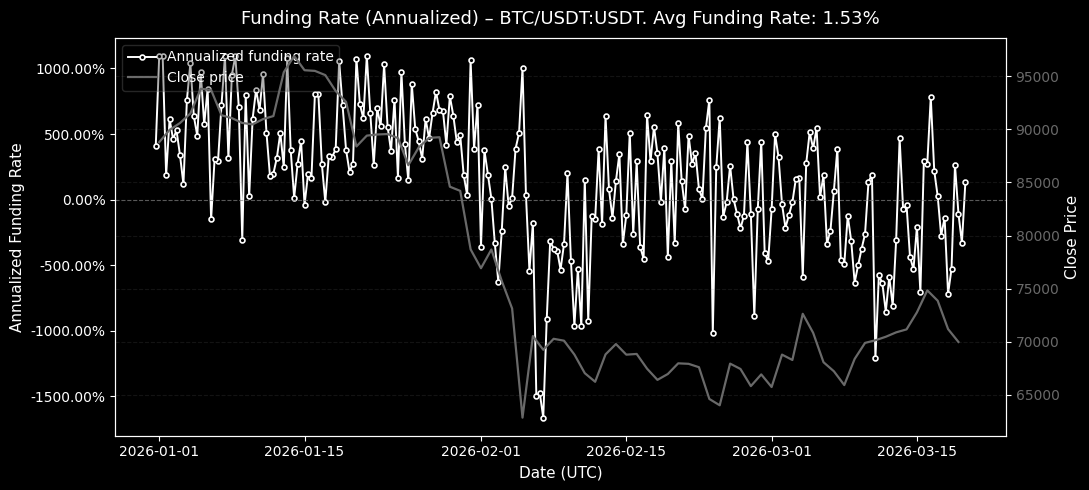

In [7]:
plt.style.use('dark_background')
fig, ax1 = plt.subplots(figsize=(11, 5))

ax1.plot(
    pd_funding_history['datetime_utc'],
    pd_funding_history['funding_rate_annualized'],
    color='white',
    linewidth=1.4,
    marker='o',
    markersize=3.5,
    markerfacecolor='black',
    markeredgecolor='white',
    markeredgewidth=1.2,
    label='Annualized funding rate'
)
ax1.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax1.set_xlabel('Date (UTC)', fontsize=11)
ax1.set_ylabel('Annualized Funding Rate', fontsize=11)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.2f}%'))
ax1.tick_params(axis='y', labelcolor='white')

ax2 = ax1.twinx()
ax2.plot(
    pd_candles['datetime_utc'],
    pd_candles['close'],
    color='dimgray',
    linewidth=1.6,
    label='Close price'
)
ax2.set_ylabel('Close Price', fontsize=11)
ax2.tick_params(axis='y', labelcolor='dimgray')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', framealpha=0.3, facecolor='black', edgecolor='gray')

plt.title(f'Funding Rate (Annualized) – {normalized_symbol}. Avg Funding Rate: {avg_funding_rate_annualized}%', fontsize=13, pad=10)
plt.grid(True, alpha=0.15, linestyle='--', color='gray')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

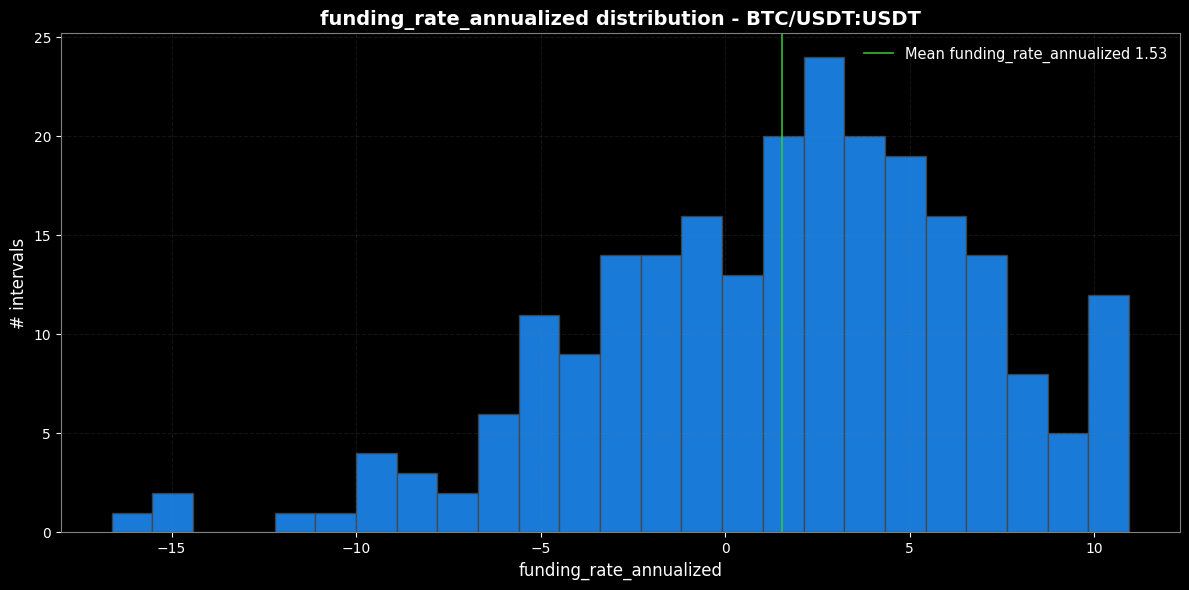

In [8]:
plt.figure(figsize=(12, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

FUNDING_RATE_UPPER_FILTER = float('inf')
plt.hist(
    pd_funding_history[pd_funding_history.funding_rate_annualized<FUNDING_RATE_UPPER_FILTER]['funding_rate_annualized'],
    bins=25,
    edgecolor='#444444',
    alpha=0.85,
    color='dodgerblue'
)
plt.axvline(avg_funding_rate_annualized, color='limegreen', linestyle='-', linewidth=1.3, alpha=0.85,
            label=f'Mean funding_rate_annualized {avg_funding_rate_annualized}')

plt.title(f'funding_rate_annualized distribution - {normalized_symbol}', 
          fontsize=14, fontweight='bold', color='white')
plt.xlabel('funding_rate_annualized', fontsize=12, color='white')
plt.ylabel('# intervals', fontsize=12, color='white')

plt.grid(True, alpha=0.15, linestyle='--', color='gray')
plt.legend(loc='upper right', frameon=False, fontsize=10.5, labelcolor='white')

ax.tick_params(colors='white', which='both')
ax.spines['bottom'].set_color('gray')
ax.spines['top'].set_color('gray')
ax.spines['left'].set_color('gray')
ax.spines['right'].set_color('gray')

plt.tight_layout()
plt.show()

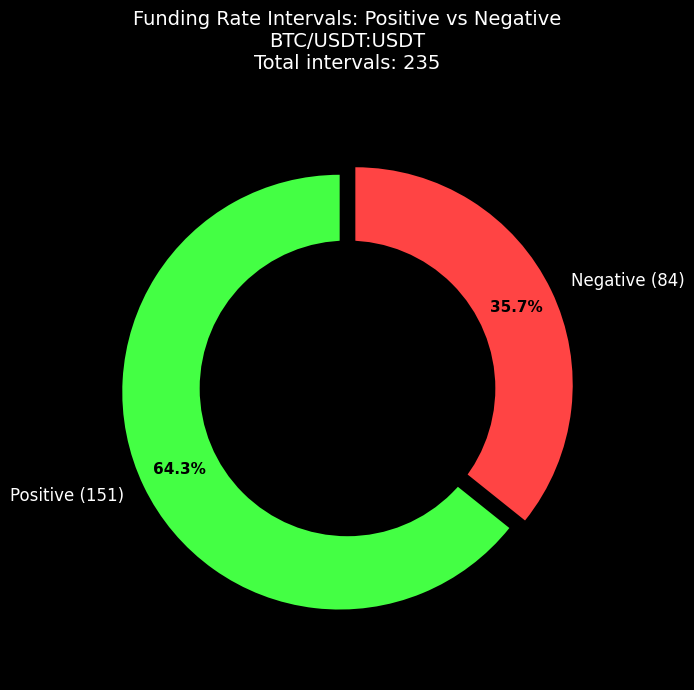

In [9]:

plt.style.use('dark_background')

positive = (pd_funding_history['funding_rate_annualized'] > 0).sum()
negative = (pd_funding_history['funding_rate_annualized'] < 0).sum()
zero = len(pd_funding_history) - positive - negative

labels = []
sizes = []
colors = []

if positive > 0:
    labels.append(f'Positive ({positive})')
    sizes.append(positive)
    colors.append('#44ff44')

if negative > 0:
    labels.append(f'Negative ({negative})')
    sizes.append(negative)
    colors.append('#ff4444')

if zero > 0:
    labels.append(f'Zero ({zero})')
    sizes.append(zero)
    colors.append('#777777')

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.82,
    explode=[0.04] * len(sizes),
    shadow=False,
    textprops={'fontsize': 12, 'color': 'white'},
)

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

ax.axis('equal')

plt.title(f'Funding Rate Intervals: Positive vs Negative\n{normalized_symbol}\n'
          f'Total intervals: {len(pd_funding_history)}', 
          fontsize=14, pad=20)

centre_circle = plt.Circle((0,0), 0.68, fc='black')
fig.gca().add_artist(centre_circle)

plt.tight_layout()
plt.show()